In [1]:
import os
import mudata as mu
import pertpy as pt
import scanpy as sc
import pandas as pd
import mudata as mu
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

milo = pt.tl.Milo()

from pertpy.tools import Milo


In [2]:
adata_age_cd8= sc.read_h5ad("/scratch/user/s4575250/BIOX7014_Thesis/write/03_batch_expression/PICA_Batch001-Batch007/PICA_Batch001-Batch007_cd8_combined_annot_with_age_scvi.h5ad")

In [3]:
adata_age_cd8

AnnData object with n_obs × n_vars = 265568 × 38606
    obs: 'status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'status_manual', 'cell_type', 'broad_cell_type', 'pica_broad_cell_type', 'pica_cell_type', 'pica_cell_type_01_myeloid', 'pica_cell_type_02_b', 'pica_cell_type_03_nk_t', 'pica_cell_type_complete', 'pica_broad_cell_type_complete', 'pica_broad_cell_type_complete_01_gdT_corrected', 'pica_cell_type_complete_01_gdT_corrected', 'status_manual_01_pica', 'Record ID', 'Sex', 'Age_years', 'Age', 'Event Name', 'Was baseline blood sample collected?', 'IFC ID', "Child's sex", 'Age in 

In [4]:
adata_age_cd8.obs['pica_cell_type_complete_01_gdT_corrected'].unique()
adata_age_cd8.obs['pica_cell_type_complete_01_gdT_corrected'].value_counts()

pica_cell_type_complete_01_gdT_corrected
CD8 naive/Tcm          175694
CD8 Tem                 50185
CD8 GZMK+ naive/Tcm     39689
Name: count, dtype: int64

In [5]:
adata_age_cd8.obs["pica_id"].unique()
adata_age_cd8.obs["pica_id"].value_counts()

pica_id
PICA0040    3781
PICA0141    3695
PICA0022    3481
PICA0140    3303
PICA0173    3213
            ... 
PICA0010     585
PICA0005     484
PICA0003     441
PICA0002     396
PICA0004     393
Name: count, Length: 128, dtype: int64

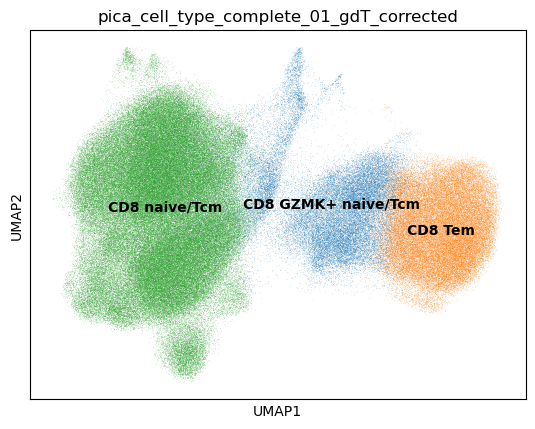

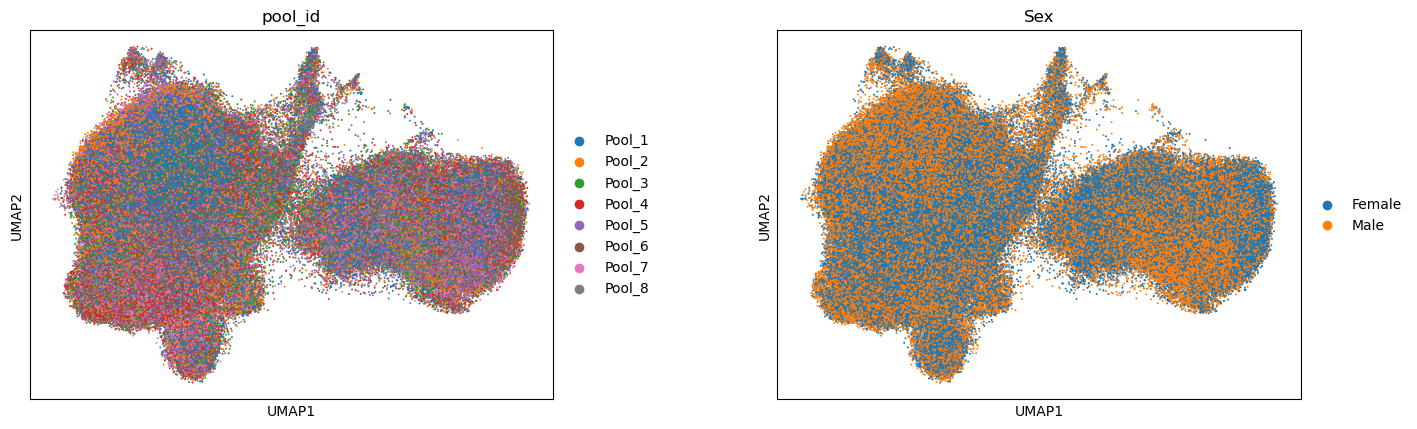

In [6]:
sc.pl.umap(adata_age_cd8, color=["pica_cell_type_complete_01_gdT_corrected"], legend_loc="on data")
sc.pl.umap(adata_age_cd8, color=["pool_id", "Sex"], wspace=0.3, size=8)

### Prepare for Milo analysis

In [7]:

adata_age_cd8.obs["Batch"] = adata_age_cd8.obs["Batch"].astype("category")
adata_age_cd8.obs["Age_years"] = adata_age_cd8.obs["Age_years"].astype("float")
adata_age_cd8.obs["Sex"] = adata_age_cd8.obs["Sex"].astype("category")
adata_age_cd8.obs["Age"] = adata_age_cd8.obs["Age"].astype("int")

In [8]:
adata_age_cd8.obs["Sex"].value_counts()


Sex
Male      152037
Female    113531
Name: count, dtype: int64

In [9]:
adata_age_cd8.obs["Age_years"].value_counts().sort_index()

Age_years
0.05     1489
0.07      585
0.14      663
0.35     2293
0.48     1267
         ... 
16.16    1848
16.20    2413
16.29    2501
16.78    1559
17.03    3096
Name: count, Length: 122, dtype: int64

In [10]:
adata_age_cd8.obs["Age_group"].value_counts().sort_index()

Age_group
0–3      58370
4–6      64945
7–10     43721
11–14    72625
15–18    25907
Name: count, dtype: int64

In [11]:
adata_age_cd8.obs["Age"].value_counts().sort_index()

Age
0     15038
1      9466
2     15862
3     18004
4     27429
5     14860
6     22656
7     16540
8     12849
9      7687
10     6645
11    20207
12    14386
13    14981
14    23051
15    12466
16    10345
17     3096
Name: count, dtype: int64

In [12]:
adata_age_cd8.obs.drop_duplicates(subset="pica_id").groupby(["Age_years", "Sex"]).size().reset_index(name="n_donors")

/scratch/temp/22542103/ipykernel_696396/2309978465.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata_age_cd8.obs.drop_duplicates(subset="pica_id").groupby(["Age_years", "Sex"]).size().reset_index(name="n_donors")


,Age_years,Sex,n_donors
0,0.05,Female,0
1,0.05,Male,1
2,0.07,Female,1
3,0.07,Male,0
4,0.14,Female,0
...,...,...,...
239,16.29,Male,1
240,16.78,Female,0
241,16.78,Male,1
242,17.03,Female,1


In [13]:
adata_age_cd8.obs.drop_duplicates(subset="pica_id").groupby(["Age", "Sex"]).size().reset_index(name="n_donors")

/scratch/temp/22542103/ipykernel_696396/587457404.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata_age_cd8.obs.drop_duplicates(subset="pica_id").groupby(["Age", "Sex"]).size().reset_index(name="n_donors")


,Age,Sex,n_donors
0,0,Female,3
1,0,Male,7
2,1,Female,1
3,1,Male,4
4,2,Female,1
5,2,Male,7
6,3,Female,6
7,3,Male,2
8,4,Female,6
9,4,Male,6


In [14]:
milo = pt.tl.Milo()
mdata_cd8 = milo.load(adata_age_cd8)

In [15]:
mdata_cd8

MuData object with n_obs × n_vars = 265568 × 38606
  2 modalities
    rna:	265568 x 38606
      obs:	'status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'status_manual', 'cell_type', 'broad_cell_type', 'pica_broad_cell_type', 'pica_cell_type', 'pica_cell_type_01_myeloid', 'pica_cell_type_02_b', 'pica_cell_type_03_nk_t', 'pica_cell_type_complete', 'pica_broad_cell_type_complete', 'pica_broad_cell_type_complete_01_gdT_corrected', 'pica_cell_type_complete_01_gdT_corrected', 'status_manual_01_pica', 'Record ID', 'Sex', 'Age_years', 'Age', 'Event Name', 'Was baseline blood sample collected?', 'IFC ID', "Child's sex", 'Age in years at the time of collection', 'Age in months at the time of collection', '1) Does your child have any significant health issue or condition?', 'Date and time of blood collection', '4) Does your child have any allergies diagnosed by a medical practitioner?', '5) Has your child shown any allergic symptoms within the last 2 months?', '7) Is your child on any medication? (including immune-modulating medications like steroids in the last two weeks)?', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=No)', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Child)', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Family member(s))', 'My family member has a history of (specify family member)', 'My child has a history of:  (Specify diagnosis date)', '8) Has your child ever been breastfed?', "9) What is your child's ethnicity? (choice=White Australian)", "9) What is your child's ethnicity? (choice=Australian Aboriginal)", "9) What is your child's ethnicity? (choice=Australian South Sea Islander)", "9) What is your child's ethnicity? (choice=Torres Strait Islander)", "9) What is your child's ethnicity? (choice=Māori)", "9) What is your child's ethnicity? (choice=New Zealander)", "9) What is your child's ethnicity? (choice=Pacific Islander)", "9) What is your child's ethnicity? (choice=North-West European)", "9) What is your child's ethnicity? (choice=Southern and Eastern European)", "9) What is your child's ethnicity? (choice=North African and Middle Eastern)", "9) What is your child's ethnicity? (choice=South-East Asian)", "9) What is your child's ethnicity? (choice=North-East Asian)", "9) What is your child's ethnicity? (choice=Southern and Central Asian)", "9) What is your child's ethnicity? (choice=Latin American and Caribbean)", "9) What is your child's ethnicity? (choice=Sub-Saharan African)", "9) What is your child's ethnicity? (choice=Decline to answer)", "9) What is your child's ethnicity? (choice=Other, please specify:)", 'Specify ethnicity', 'Batch', 'Age_group'
      var:	'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb'
      uns:	'Batch_colors', '_scvi_manager_uuid', '_scvi_uuid', 'cell_type_colors', 'neighbors', 'pica_cell_type_complete_01_gdT_corrected_colors', 'sequencing_batch_colors', 'umap', 'pool_id_colors', 'Sex_colors'
      obsm:	'X_scVI', 'X_umap'
      layers:	'counts'
      obsp:	'connectivities', 'distances'
    milo:	0 x 0

In [16]:
# Build KNN graph
sc.pp.neighbors(mdata_cd8["rna"], use_rep="X_scVI", n_neighbors=150)

In [17]:
# Build neighbourhood graph
milo.make_nhoods(mdata_cd8["rna"], prop=0.1)

In [18]:
mdata_cd8["rna"].obsm["nhoods"]

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 6755188 stored elements and shape (265568, 13739)>

In [19]:
mdata_cd8["rna"][mdata_cd8["rna"].obs["nhood_ixs_refined"] != 0].obs[["nhood_ixs_refined", "nhood_kth_distance"]]

,nhood_ixs_refined,nhood_kth_distance
20240918_WGS_20240924_sc_PICA0008-PICA0032_Pool_5_AAATCACTCAGCGCAT,1,3.265390
20240918_WGS_20240924_sc_PICA0008-PICA0032_Pool_5_AAATGTCTCAGGACTC,1,3.257657
20240918_WGS_20240924_sc_PICA0008-PICA0032_Pool_5_AACATAACAGTCCATG,1,3.009837
20240918_WGS_20240924_sc_PICA0008-PICA0032_Pool_5_AACCTTACAATACGGA,1,3.541760
20240918_WGS_20240924_sc_PICA0008-PICA0032_Pool_5_AACGGGCAGGTACGTC,1,3.219984
...,...,...
20240530_WGS_20240530_sc_PICA0001-PICA0007_Pool_2_GCCTTTCCACATGTCG,1,3.201525
20240530_WGS_20240530_sc_PICA0001-PICA0007_Pool_2_GCGCAATTCACTTCCG,1,3.723792
20240530_WGS_20240530_sc_PICA0001-PICA0007_Pool_2_GGAACTTGTGGAATGA,1,3.386278
20240530_WGS_20240530_sc_PICA0001-PICA0007_Pool_2_GGTTAATTCATGTGGC,1,3.204317


Text(0, 0.5, '# nhoods')

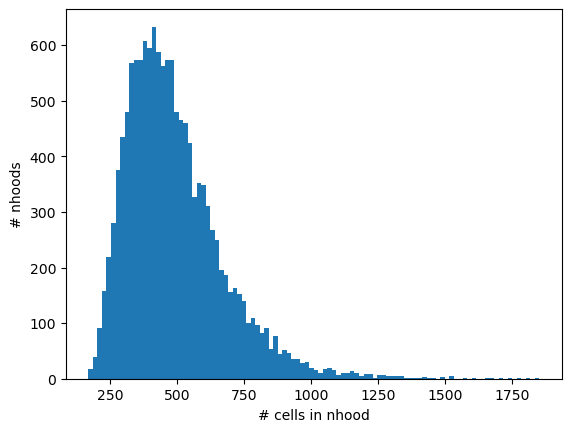

In [20]:
nhood_size = np.array(mdata_cd8["rna"].obsm["nhoods"].sum(0)).ravel()
plt.hist(nhood_size, bins=100)
plt.xlabel("# cells in nhood")
plt.ylabel("# nhoods")

In [21]:
# count cells in neighbourhood
mdata_cd8= milo.count_nhoods(mdata_cd8, sample_col="pica_id") 

In [22]:
mdata_cd8

MuData object with n_obs × n_vars = 265568 × 38606
  2 modalities
    rna:	265568 x 38606
      obs:	'status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'status_manual', 'cell_type', 'broad_cell_type', 'pica_broad_cell_type', 'pica_cell_type', 'pica_cell_type_01_myeloid', 'pica_cell_type_02_b', 'pica_cell_type_03_nk_t', 'pica_cell_type_complete', 'pica_broad_cell_type_complete', 'pica_broad_cell_type_complete_01_gdT_corrected', 'pica_cell_type_complete_01_gdT_corrected', 'status_manual_01_pica', 'Record ID', 'Sex', 'Age_years', 'Age', 'Event Name', 'Was baseline blood sample collected?', 'IFC ID', "Child's sex", 'Age in years at the time of collection', 'Age in months at the time of collection', '1) Does your child have any significant health issue or condition?', 'Date and time of blood collection', '4) Does your child have any allergies diagnosed by a medical practitioner?', '5) Has your child shown any allergic symptoms within the last 2 months?', '7) Is your child on any medication? (including immune-modulating medications like steroids in the last two weeks)?', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=No)', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Child)', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Family member(s))', 'My family member has a history of (specify family member)', 'My child has a history of:  (Specify diagnosis date)', '8) Has your child ever been breastfed?', "9) What is your child's ethnicity? (choice=White Australian)", "9) What is your child's ethnicity? (choice=Australian Aboriginal)", "9) What is your child's ethnicity? (choice=Australian South Sea Islander)", "9) What is your child's ethnicity? (choice=Torres Strait Islander)", "9) What is your child's ethnicity? (choice=Māori)", "9) What is your child's ethnicity? (choice=New Zealander)", "9) What is your child's ethnicity? (choice=Pacific Islander)", "9) What is your child's ethnicity? (choice=North-West European)", "9) What is your child's ethnicity? (choice=Southern and Eastern European)", "9) What is your child's ethnicity? (choice=North African and Middle Eastern)", "9) What is your child's ethnicity? (choice=South-East Asian)", "9) What is your child's ethnicity? (choice=North-East Asian)", "9) What is your child's ethnicity? (choice=Southern and Central Asian)", "9) What is your child's ethnicity? (choice=Latin American and Caribbean)", "9) What is your child's ethnicity? (choice=Sub-Saharan African)", "9) What is your child's ethnicity? (choice=Decline to answer)", "9) What is your child's ethnicity? (choice=Other, please specify:)", 'Specify ethnicity', 'Batch', 'Age_group', 'nhood_ixs_random', 'nhood_ixs_refined', 'nhood_kth_distance'
      var:	'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb'
      uns:	'Batch_colors', '_scvi_manager_uuid', '_scvi_uuid', 'cell_type_colors', 'neighbors', 'pica_cell_type_complete_01_gdT_corrected_colors', 'sequencing_batch_colors', 'umap', 'pool_id_colors', 'Sex_colors', 'nhood_neighbors_key'
      obsm:	'X_scVI', 'X_umap', 'nhoods'
      layers:	'counts'
      obsp:	'connectivities', 'distances'
    milo:	128 x 13739
      var:	'index_cell', 'kth_distance'
      uns:	'sample_col'

In [23]:
mdata_cd8["milo"]

AnnData object with n_obs × n_vars = 128 × 13739
    var: 'index_cell', 'kth_distance'
    uns: 'sample_col'

In [24]:
donor_meta_cd8 = (
    adata_age_cd8.obs[["pica_id", "Age_years","Age", "Sex", "Batch","Age_group"]]
    .drop_duplicates("pica_id")
    .set_index("pica_id")
)
donor_meta_cd8 = donor_meta_cd8.loc[mdata_cd8["milo"].obs_names]

In [25]:
mdata_cd8["milo"].obs["Age_years"] = donor_meta_cd8["Age_years"].values
mdata_cd8["milo"].obs["Sex"] = donor_meta_cd8["Sex"].values
mdata_cd8["milo"].obs["Batch"] = donor_meta_cd8["Batch"].values
mdata_cd8["milo"].obs["Age"] = donor_meta_cd8["Age"].values
mdata_cd8["milo"].obs["Age_group"] = donor_meta_cd8["Age_group"].values

In [26]:

mdata_cd8["milo"].obs["Sex"] = mdata_cd8["milo"].obs["Sex"].astype("category")
mdata_cd8["milo"].obs["Age_years"] = mdata_cd8["milo"].obs["Age_years"].astype("float")
mdata_cd8["milo"].obs["Batch"] = mdata_cd8["milo"].obs["Batch"].astype("category")
mdata_cd8["milo"].obs["Age"] = mdata_cd8["milo"].obs["Age"].astype("int")
mdata_cd8["milo"].obs["Age_group"] = mdata_cd8["milo"].obs["Age_group"].astype("category")

In [27]:
donor_meta_cd8

,Age_years,Age,Sex,Batch,Age_group
PICA0001,2.09,2,Male,Batch01,0–3
PICA0002,15.09,15,Male,Batch01,15–18
PICA0003,0.83,0,Male,Batch01,0–3
PICA0004,1.46,1,Male,Batch01,0–3
PICA0005,9.30,9,Male,Batch01,7–10
...,...,...,...,...,...
PICA0164,2.15,2,Male,Batch07,0–3
PICA0166,0.62,0,Male,Batch07,0–3
PICA0168,16.20,16,Male,Batch07,15–18
PICA0169,2.72,2,Male,Batch07,0–3


In [28]:
mdata_cd8["milo"]

AnnData object with n_obs × n_vars = 128 × 13739
    obs: 'Age_years', 'Sex', 'Batch', 'Age', 'Age_group'
    var: 'index_cell', 'kth_distance'
    uns: 'sample_col'

In [29]:
mdata_cd8.write_h5mu(
    "/scratch/user/s4575250/BIOX7014_Thesis/write/03_milo_DA/PICA_Batch001-Batch007/PICA_Batch001-Batch007_cd8_milo_nhoods_built.h5mu"
)

In [30]:
mdata_cd8["milo"].obs["Age_years"].value_counts().sort_index()

Age_years
0.05     1
0.07     1
0.14     1
0.35     1
0.48     1
        ..
16.16    1
16.20    1
16.29    1
16.78    1
17.03    1
Name: count, Length: 122, dtype: int64

In [31]:
mdata_cd8["milo"].obs["Sex"].value_counts().sort_index()

Sex
Female    53
Male      75
Name: count, dtype: int64

In [32]:
mdata_cd8["milo"].obs["Age_group"].value_counts().sort_index()

Age_group
0–3      31
4–6      29
7–10     21
11–14    34
15–18    13
Name: count, dtype: int64

In [33]:
mdata_cd8["milo"]

AnnData object with n_obs × n_vars = 128 × 13739
    obs: 'Age_years', 'Sex', 'Batch', 'Age', 'Age_group'
    var: 'index_cell', 'kth_distance'
    uns: 'sample_col'

In [34]:
mdata_cd8

MuData object with n_obs × n_vars = 265696 × 52345
  2 modalities
    rna:	265568 x 38606
      obs:	'status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'status_manual', 'cell_type', 'broad_cell_type', 'pica_broad_cell_type', 'pica_cell_type', 'pica_cell_type_01_myeloid', 'pica_cell_type_02_b', 'pica_cell_type_03_nk_t', 'pica_cell_type_complete', 'pica_broad_cell_type_complete', 'pica_broad_cell_type_complete_01_gdT_corrected', 'pica_cell_type_complete_01_gdT_corrected', 'status_manual_01_pica', 'Record ID', 'Sex', 'Age_years', 'Age', 'Event Name', 'Was baseline blood sample collected?', 'IFC ID', "Child's sex", 'Age in years at the time of collection', 'Age in months at the time of collection', '1) Does your child have any significant health issue or condition?', 'Date and time of blood collection', '4) Does your child have any allergies diagnosed by a medical practitioner?', '5) Has your child shown any allergic symptoms within the last 2 months?', '7) Is your child on any medication? (including immune-modulating medications like steroids in the last two weeks)?', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=No)', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Child)', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Family member(s))', 'My family member has a history of (specify family member)', 'My child has a history of:  (Specify diagnosis date)', '8) Has your child ever been breastfed?', "9) What is your child's ethnicity? (choice=White Australian)", "9) What is your child's ethnicity? (choice=Australian Aboriginal)", "9) What is your child's ethnicity? (choice=Australian South Sea Islander)", "9) What is your child's ethnicity? (choice=Torres Strait Islander)", "9) What is your child's ethnicity? (choice=Māori)", "9) What is your child's ethnicity? (choice=New Zealander)", "9) What is your child's ethnicity? (choice=Pacific Islander)", "9) What is your child's ethnicity? (choice=North-West European)", "9) What is your child's ethnicity? (choice=Southern and Eastern European)", "9) What is your child's ethnicity? (choice=North African and Middle Eastern)", "9) What is your child's ethnicity? (choice=South-East Asian)", "9) What is your child's ethnicity? (choice=North-East Asian)", "9) What is your child's ethnicity? (choice=Southern and Central Asian)", "9) What is your child's ethnicity? (choice=Latin American and Caribbean)", "9) What is your child's ethnicity? (choice=Sub-Saharan African)", "9) What is your child's ethnicity? (choice=Decline to answer)", "9) What is your child's ethnicity? (choice=Other, please specify:)", 'Specify ethnicity', 'Batch', 'Age_group', 'nhood_ixs_random', 'nhood_ixs_refined', 'nhood_kth_distance'
      var:	'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb'
      uns:	'Batch_colors', '_scvi_manager_uuid', '_scvi_uuid', 'cell_type_colors', 'neighbors', 'pica_cell_type_complete_01_gdT_corrected_colors', 'sequencing_batch_colors', 'umap', 'pool_id_colors', 'Sex_colors', 'nhood_neighbors_key'
      obsm:	'X_scVI', 'X_umap', 'nhoods'
      layers:	'counts'
      obsp:	'connectivities', 'distances'
    milo:	128 x 13739
      obs:	'Age_years', 'Sex', 'Batch', 'Age', 'Age_group'
      var:	'ind